# Simple Gurobi Battery Model with price as a simple function of AIL

In [12]:
# Let's start off by loading in the packages
import pandas as pd
import datetime
import os
import timeit
import matplotlib.pyplot as plt
import gurobipy as gp
from gurobipy import GRB
import numpy as np
from scipy.optimize import curve_fit
from scipy.stats import beta

In [13]:
# Loading in the data first.
# Let's load in the data here, and for now, let's make it just for four hours.

file_name = os.fsdecode("marco_data.csv")
workbook = pd.read_csv(file_name)
workbook = workbook.filter(items=["date", "he", "size","flexible","price","ail","mkt_price"]) # Gets the columns that we need


workbook = workbook.query('date=="2024-04-10"') # Remove this to take out the filter for the day.

# Getting the columns we need.
# merit_data = workbook.filter(items=["date", "he", "size","flexible","price","mkt_price","ail","datetime"]) # Gets the columns that we need
merit_data = workbook
# I added "datetime" above so that it will be easier to filter out the merit data when looping through.

In [14]:
merit_data

,date,he,size,flexible,price,ail,mkt_price
0,2024-04-10,1,0.0124,N,0.00,9169.9227,68.48
1,2024-04-10,1,0.0261,N,0.00,9169.9227,68.48
2,2024-04-10,1,0.0351,N,0.00,9169.9227,68.48
3,2024-04-10,1,0.1579,N,0.00,9169.9227,68.48
4,2024-04-10,1,0.9010,N,0.00,9169.9227,68.48
...,...,...,...,...,...,...,...
6131,2024-04-10,24,16.0000,Y,999.99,8518.8169,45.04
6132,2024-04-10,24,16.0000,Y,999.99,8518.8169,45.04
6133,2024-04-10,24,80.0000,Y,999.99,8518.8169,45.04
6134,2024-04-10,24,85.0000,Y,999.99,8518.8169,45.04


In [15]:
# Adding in battery data:

#### BATTERY DATA ####

# Creating the parameters of the battery here, and if we want to make changes to our battery this is where we can adjust it.
batt_dict = {
    'max_charge_rate':100,
    'max_discharge_rate':100,
    'capacity':400,
    'charge_eff':0.05,
    'discharge_eff':0.05,
    'min_soc':0.05,
    'max_soc':0.95,
    'initial_soc':200
}

battDF = pd.DataFrame.from_dict(batt_dict, orient = 'index').transpose()
del batt_dict
battDF

,max_charge_rate,max_discharge_rate,capacity,charge_eff,discharge_eff,min_soc,max_soc,initial_soc
0,100.0,100.0,400.0,0.05,0.05,0.05,0.95,200.0


In [16]:
# Let's create a simple price function that we'll use in the gurobi model
def simple_price(x):
    return (0.5*x)

In [17]:
# And now let's create an index
time_index = merit_data['he'].unique()

# And then let's get the ail for each hour:
ail_list = merit_data.groupby(by = 'he',as_index = False)['ail'].min()['ail']

In [18]:
# Now we start with creating the gurobi model.

bm = gp.Model("qp")

inf = GRB.INFINITY

In [19]:
## Let's create the variables
# It's slightly different now because we're using Gurobi

# Create an index for the number of periods that's an integer; easier to use.
tIndex = len(time_index)

# Now creating the variables of a simpler battery
vBattPower = [bm.addVar(lb = -inf, ub = inf, name = "") for _ in range(tIndex)]
# Battery State of Charge Variable, which acts as a constraint as well.
vSOC = [bm.addVar(lb = battDF.iloc[0]['capacity']*battDF.iloc[0]['min_soc'], ub = battDF.iloc[0]['capacity']*battDF.iloc[0]['max_soc'], name = "") for _ in range(tIndex)]

# Simple Price function that governs prices:
vPrice = [bm.addVar(lb = -inf, ub = inf, name = "") for _ in range(tIndex)]

In [20]:
## CONSTRAINTS

for i in range(tIndex):

    #---------------------------------------------------------------------------------------------------------------------------
    #### Battery Constraints:

    # Power flow constraints
    bm.addConstr(vBattPower[i] >= -battDF.iloc[0]['max_discharge_rate'])
    bm.addConstr(vBattPower[i] <= battDF.iloc[0]['max_charge_rate'])

    # Law of Motion for the state of charge of the battery:
    # NOTE: Because we are doing it this way, if BattPower is positive then our battery is charging.
    if i == 0:
        bm.addConstr(vSOC[i] == battDF.iloc[0]['initial_soc'] + vBattPower[i])
    else:
        bm.addConstr(vSOC[i] == vSOC[i-1] + vBattPower[i])

    #### Price Constraint:
    bm.addConstr(vPrice[i] == simple_price(ail_list[i] + vBattPower[i]))

    #---------------------------------------------------------------------------------------------------------------------------


    

In [21]:
#---------------------------------------------------------------
# Objective Function Setup

# Add objective
# Changed the objective to sum up the battery energy times the price, instead of power in the grid.
obj = 0
obj += sum([vPrice[i]*vBattPower[i] for i in range(tIndex)])
# obj += sum([approx_prices[i]*vBattPower[i] for i in range(tIndex)])

# Setting the objective
bm.setObjective(obj, GRB.MINIMIZE)
#---------------------------------------------------------------

In [22]:
# Command that tells gurobi to optimize the model.

bm.optimize()

Gurobi Optimizer version 11.0.3 build v11.0.3rc0 (win64 - Windows 11.0 (22631.2))

CPU model: 12th Gen Intel(R) Core(TM) i7-12800H, instruction set [SSE2|AVX|AVX2]
Thread count: 14 physical cores, 20 logical processors, using up to 20 threads

Academic license 2565375 - for non-commercial use only - registered to al___@ualberta.ca
Optimize a model with 96 rows, 72 columns and 167 nonzeros
Model fingerprint: 0xe9b950ce
Model has 24 quadratic objective terms
Coefficient statistics:
  Matrix range     [5e-01, 1e+00]
  Objective range  [0e+00, 0e+00]
  QObjective range [2e+00, 2e+00]
  Bounds range     [2e+01, 4e+02]
  RHS range        [1e+02, 5e+03]
Presolve removed 49 rows and 1 columns

Continuous model is non-convex -- solving as a MIP

Presolve removed 49 rows and 1 columns
Presolve time: 0.00s
Presolved: 96 rows, 96 columns, 286 nonzeros
Presolved model has 24 bilinear constraint(s)
Variable types: 96 continuous, 0 integer (0 binary)
Found heuristic solution: objective -1001712.004



In [23]:
# Let's collect the battery power values and the price values:
prices = []
batt_power = []
state_of_charge = []

for i in range(tIndex):
    prices.append(vPrice[i].X)
    batt_power.append(vBattPower[i].X)
    state_of_charge.append(vSOC[i].X)





In [117]:
# Let's put our results in a table:

battery_results = pd.DataFrame()

battery_results['hour_ending'] = merit_data['he'].unique()
battery_results['simple_prices'] = prices
battery_results['batt_power'] = batt_power
battery_results['state_of_charge'] = state_of_charge

battery_results

,hour_ending,simple_prices,batt_power,state_of_charge
0,1,4539.391792,-91.139117,108.860883
1,2,4481.065342,25.513783,134.374667
2,3,4443.973492,99.697483,234.072150
3,4,4452.630517,82.383433,316.455583
4,5,4470.866992,45.910483,362.366067
5,6,4485.005267,17.633933,380.000000
6,7,4596.093000,-9.411500,370.588500
7,8,4586.681500,9.411500,380.000000
8,9,4766.122200,0.000000,380.000000
9,10,4865.623000,0.000000,380.000000


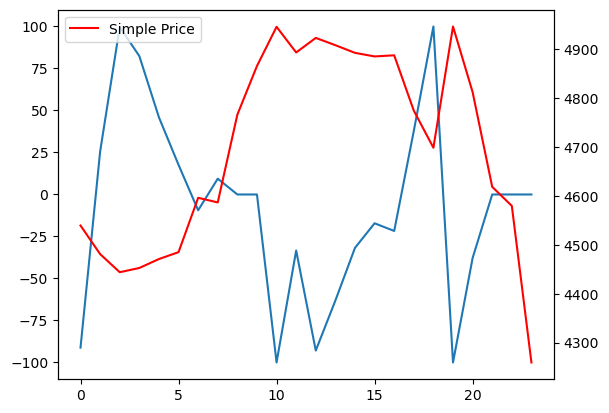

In [118]:
# Plotting the results

# And now we plot to be able to see:

fig, ax1 = plt.subplots()

ax2 = ax1.twinx()

ax1.plot(range(tIndex),batt_power, label = "Battery Activity")
ax2.plot(range(tIndex),prices, color = 'red', label = "Simple Price")
# ax2.plot(range(tIndex),state_of_charge, color = 'red', label = "Market Price")

plt.legend()
plt.show()